In [208]:
import mne
import matplotlib.pyplot as plt

In [209]:
raw = mne.io.read_raw_fif("data_testing/30_sec.fif", preload=True)

Opening raw data file data_testing/30_sec.fif...
    Range : 0 ... 8724 =      0.000 ...    34.896 secs
Ready.
Reading 0 ... 8724  =      0.000 ...    34.896 secs...


/tmp/ipykernel_25896/1111135953.py:1: RuntimeWarning: This filename (data_testing/30_sec.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif("data_testing/30_sec.fif", preload=True)


# Info

In [210]:
print(raw.info)

<Info | 10 non-empty values
 bads: []
 ch_names: F4, F3, C4, C3, P4, P3, O2, O1, Accel_x, Accel_y, Accel_z, Sample
 chs: 8 EEG, 3 misc, 1 System status channel information (Triux systems)
 custom_ref_applied: False
 dig: 11 items (3 Cardinal, 8 EEG)
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 12
 projs: []
 sfreq: 250.0 Hz
>


# Show one channel

In [211]:
cos = raw.get_data()

In [212]:
cos

array([[ 1.74406907e+05,  1.74131779e+05,  1.73904127e+05, ...,
         1.90595448e+05,  1.90590687e+05,  1.90594979e+05],
       [ 1.76191247e+05,  1.76164492e+05,  1.75819358e+05, ...,
         1.60470214e+05,  1.60468404e+05,  1.60464984e+05],
       [ 1.10846056e+05,  1.10661319e+05,  1.10304115e+05, ...,
         2.09512266e+05,  2.09509115e+05,  2.09517429e+05],
       ...,
       [-1.98878872e+00, -1.98878872e+00, -1.98878872e+00, ...,
        -1.49159157e+00, -1.49159157e+00, -1.49159157e+00],
       [ 1.52983755e-01,  1.52983755e-01,  1.52983755e-01, ...,
         1.56808352e+00,  1.56808352e+00,  1.56808352e+00],
       [ 0.00000000e+00,  1.00000000e+00,  2.00000000e+00, ...,
         8.72200000e+03,  8.72300000e+03,  8.72400000e+03]],
      shape=(12, 8725))

In [213]:
time = cos[11]
val = cos[0]

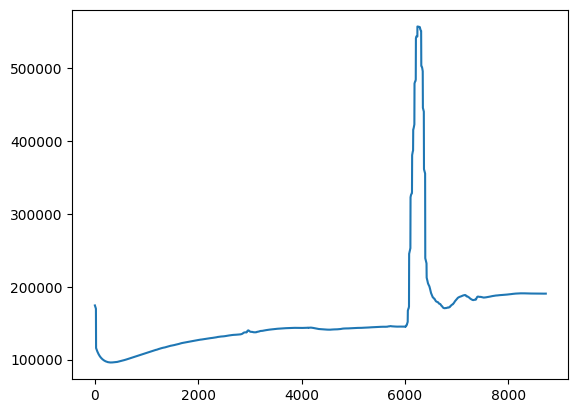

In [214]:
plt.plot(val)
plt.show()

# Compare Data before and after filtering

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/home/sergiusz/BrainGradient/.venv/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


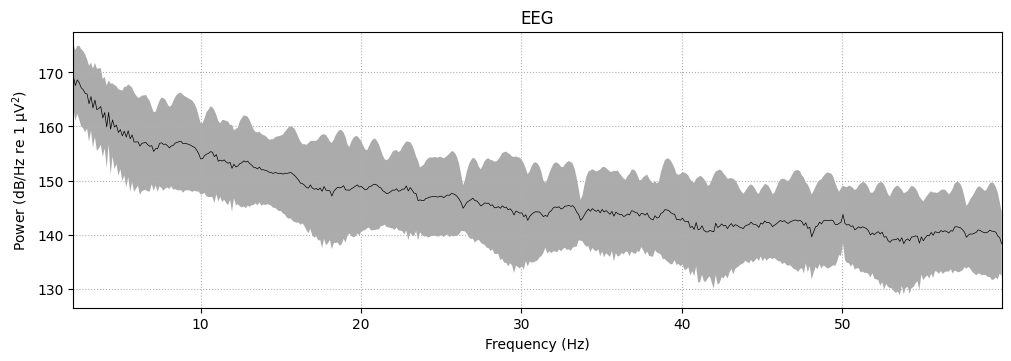

In [215]:
raw.plot_psd(tmin=0, tmax=60, fmin=2, fmax=60, average=True, spatial_colors=False)

In [216]:
raw.notch_filter(50,)
# 2 Hz to 42 Hz
raw.filter(2, 42)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 2 - 42 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 2.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.00 Hz)
- Upper passband edge

<Raw | 30_sec.fif, 12 x 8725 (34.9 s), ~840 KiB, data loaded>

# Dominance Calclulation

In [217]:
psd = raw.compute_psd(tmin=0, tmax=60, fmin=2, fmax=50)

Effective window size : 8.192 (s)


In [224]:
alpha = [8,13] # Alpha:   8   – 13  Hz   → Relaxed wakefulness, calm focus
beta = [13,30] # Beta:    13  – 30  Hz   → Active thinking, alertness, problem-solving
bands_freq = [alpha, beta]
bands_names = ['Alpha', 'Beta']

In [257]:
def get_power_band(spectrum:mne.time_frequency.Spectrum, band:list):
    fmin, fmax = band
    power, freqs = spectrum.get_data(return_freqs=True, fmin=fmin, fmax=fmax)
    return power, freqs

def extract_all_power_bands(spectrum:mne.time_frequency.Spectrum):
    power_bands = []
    for band in bands_freq:
        power_bands.append(get_power_band(spectrum, band))
    return power_bands

def sum_channels(power) -> float:
    n = 0
    band_sum = 0
    for ch in power:
        for val in ch:
            n+=1
            band_sum += val
    return band_sum / n

In [226]:
bands = extract_all_power_bands(psd)

In [259]:
alpha = bands[0]
beta = bands[1]

a_sum = sum_channels(alpha[0])
b_sum = sum_channels(beta[0])

In [261]:
dominance = (a_sum + b_sum) / 2